# xGEO candidate fuel-station cost matrix

This notebook creates a common-time snapshot of the U.S. GEO targets, places a grid of *candidate* fuel-station locations on nominal circular equatorial GEO, plots targets and stations, and builds a target-by-station **one-way screening Δv matrix**.

The candidate grid is deliberately dense. A later TDA or facility-location step can decide which candidate stations to retain.

## 1. Imports and configuration

`N_CANDIDATE_STATIONS = 36` means one candidate every 10° of longitude.

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The first existing folder is used. If your notebook sits in notebooks/,
# ../data/geo_us is normally the correct choice.
DATA_DIRECTORY = next(
    (path for path in [Path('../data/geo_us'), Path('data/geo_us'), Path('upload')] if path.exists()),
    Path('../data/geo_us'),
)
STATUS_FILENAME = 'us_geo_catalog_status.csv'
HISTORY_FILENAME = 'gp_history_20260801_20260901_3cbd5060be.json'
OUTPUT_DIRECTORY = Path('outputs/xgeo_station_cost_matrix')

# Leave as None to use the latest epoch represented in the GP history.
ANALYSIS_EPOCH_UTC = None

# Candidate fuel-station grid. These stations are nominal circular, equatorial GEO slots.
N_CANDIDATE_STATIONS = 36
STATION_LONGITUDES_DEG = np.linspace(-180.0, 180.0, N_CANDIDATE_STATIONS, endpoint=False)
PHASING_REVOLUTIONS = 1

# Earth and nominal GEO constants.
MU_EARTH_KM3_S2 = 398_600.4418
GEO_RADIUS_KM = 42_164.0

print(f'Data directory: {DATA_DIRECTORY.resolve()}')
print(f'Candidate stations: {N_CANDIDATE_STATIONS}')

Data directory: C:\Users\leo.langou\OneDrive - West Point\Desktop\2027 AY-1\MA498\Space_Logistics\data\geo_us
Candidate stations: 36


## 2. Load targets and choose the latest valid orbital state

The status catalog defines the target set. The history file supplies orbital elements. Satellites without a complete public state are retained in `excluded_targets` but cannot enter the cost matrix.

In [3]:
status = pd.read_csv(DATA_DIRECTORY / STATUS_FILENAME)
with (DATA_DIRECTORY / HISTORY_FILENAME).open('r', encoding='utf-8') as handle:
    history = pd.DataFrame(json.load(handle))

status['NORAD_CAT_ID'] = status['NORAD_CAT_ID'].astype(str)
history['NORAD_CAT_ID'] = history['NORAD_CAT_ID'].astype(str)
history['EPOCH'] = pd.to_datetime(history['EPOCH'], utc=True)

required_columns = [
    'EPOCH', 'MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION',
    'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'SEMIMAJOR_AXIS',
]
catalog_ids = set(status['NORAD_CAT_ID'])
states = history[history['NORAD_CAT_ID'].isin(catalog_ids)].copy()
for column in required_columns[1:]:
    states[column] = pd.to_numeric(states[column], errors='coerce')
states = states.dropna(subset=required_columns)

latest_states = (
    states.sort_values('EPOCH')
    .groupby('NORAD_CAT_ID', as_index=False)
    .tail(1)
    .reset_index(drop=True)
)
excluded_targets = status[~status['NORAD_CAT_ID'].isin(latest_states['NORAD_CAT_ID'])].copy()

print(f'Targets in status catalog: {len(status)}')
print(f'Targets with usable public orbital states: {len(latest_states)}')
print(f'Excluded targets: {len(excluded_targets)}')

Targets in status catalog: 124
Targets with usable public orbital states: 102
Excluded targets: 22


## 3. Propagate all targets to one snapshot and calculate location

This uses a transparent two-body propagation of the supplied mean elements. It produces a common Earth-fixed snapshot for visualization and longitude-based phasing costs.

In [4]:
def solve_kepler(mean_anomaly_rad, eccentricity):
    mean_anomaly_rad = np.mod(mean_anomaly_rad, 2.0 * np.pi)
    eccentric_anomaly = mean_anomaly_rad.copy()
    for _ in range(20):
        step = (eccentric_anomaly - eccentricity * np.sin(eccentric_anomaly) - mean_anomaly_rad) / (1.0 - eccentricity * np.cos(eccentric_anomaly))
        eccentric_anomaly -= step
        if np.max(np.abs(step)) < 1e-13:
            break
    return eccentric_anomaly

def gmst_rad(timestamp):
    jd = timestamp.timestamp() / 86_400.0 + 2_440_587.5
    centuries = (jd - 2_451_545.0) / 36_525.0
    gmst_deg = 280.46061837 + 360.98564736629 * (jd - 2_451_545.0) + 0.000387933 * centuries**2 - centuries**3 / 38_710_000.0
    return np.deg2rad(gmst_deg % 360.0)

def propagate_to_ecef(states, analysis_epoch):
    dt_seconds = (analysis_epoch - states['EPOCH']).dt.total_seconds().to_numpy()
    mean_motion_rad_s = states['MEAN_MOTION'].to_numpy() * 2.0 * np.pi / 86_400.0
    mean_anomaly = np.deg2rad(states['MEAN_ANOMALY'].to_numpy()) + mean_motion_rad_s * dt_seconds
    eccentricity = states['ECCENTRICITY'].to_numpy()
    eccentric_anomaly = solve_kepler(mean_anomaly, eccentricity)
    true_anomaly = 2.0 * np.arctan2(
        np.sqrt(1.0 + eccentricity) * np.sin(eccentric_anomaly / 2.0),
        np.sqrt(1.0 - eccentricity) * np.cos(eccentric_anomaly / 2.0),
    )
    a = states['SEMIMAJOR_AXIS'].to_numpy()
    radius = a * (1.0 - eccentricity * np.cos(eccentric_anomaly))
    u = np.deg2rad(states['ARG_OF_PERICENTER'].to_numpy()) + true_anomaly
    inc = np.deg2rad(states['INCLINATION'].to_numpy())
    raan = np.deg2rad(states['RA_OF_ASC_NODE'].to_numpy())

    x_eci = radius * (np.cos(raan) * np.cos(u) - np.sin(raan) * np.sin(u) * np.cos(inc))
    y_eci = radius * (np.sin(raan) * np.cos(u) + np.cos(raan) * np.sin(u) * np.cos(inc))
    z_eci = radius * np.sin(u) * np.sin(inc)
    theta = gmst_rad(analysis_epoch)
    x_ecef = np.cos(theta) * x_eci + np.sin(theta) * y_eci
    y_ecef = -np.sin(theta) * x_eci + np.cos(theta) * y_eci
    return np.column_stack([x_ecef, y_ecef, z_eci])

if ANALYSIS_EPOCH_UTC is None:
    analysis_epoch = latest_states['EPOCH'].max()
else:
    analysis_epoch = pd.Timestamp(ANALYSIS_EPOCH_UTC, tz='UTC')

target_ecef_km = propagate_to_ecef(latest_states, analysis_epoch)
targets = latest_states[['NORAD_CAT_ID', 'OBJECT_NAME', 'EPOCH', 'SEMIMAJOR_AXIS', 'ECCENTRICITY', 'INCLINATION']].copy()
targets['X_ECEF_KM'] = target_ecef_km[:, 0]
targets['Y_ECEF_KM'] = target_ecef_km[:, 1]
targets['Z_ECEF_KM'] = target_ecef_km[:, 2]
targets['LONGITUDE_RAD'] = np.arctan2(target_ecef_km[:, 1], target_ecef_km[:, 0])
targets['LONGITUDE_DEG'] = np.rad2deg(targets['LONGITUDE_RAD'])

print(f'Analysis epoch: {analysis_epoch.isoformat()}')
targets[['NORAD_CAT_ID', 'OBJECT_NAME', 'LONGITUDE_DEG', 'INCLINATION']].head()

Analysis epoch: 2026-09-03T20:48:38.536416+00:00


,NORAD_CAT_ID,OBJECT_NAME,LONGITUDE_DEG,INCLINATION
0,56372,GS-1,87.155818,2.9049
1,41745,USA 271,97.139706,4.3566
2,57479,JUPITER 3 (ECHOSTAR 24),-95.211713,0.0156
3,55263,USA 342,23.782371,0.0027
4,56370,VIASAT 3-F1,-88.996439,0.0146


## 4. Place candidate fuel stations in nominal GEO

Each candidate station has a servicing spacecraft parked on a circular, equatorial GEO orbit. The grid contains no claim that every candidate will be built.

In [5]:
station_longitudes_rad = np.deg2rad(STATION_LONGITUDES_DEG)
stations = pd.DataFrame({
    'STATION_ID': [f'FS_{index:02d}' for index in range(1, N_CANDIDATE_STATIONS + 1)],
    'LONGITUDE_DEG': STATION_LONGITUDES_DEG,
})
stations['X_ECEF_KM'] = GEO_RADIUS_KM * np.cos(station_longitudes_rad)
stations['Y_ECEF_KM'] = GEO_RADIUS_KM * np.sin(station_longitudes_rad)
stations['Z_ECEF_KM'] = 0.0
stations.head()

,STATION_ID,LONGITUDE_DEG,X_ECEF_KM,Y_ECEF_KM,Z_ECEF_KM
0,FS_01,-180.0,-42164.000000,-5.163601e-12,0.0
1,FS_02,-170.0,-41523.434098,-7.321702e+03,0.0
2,FS_03,-160.0,-39621.199663,-1.442094e+04,0.0
3,FS_04,-150.0,-36515.095125,-2.108200e+04,0.0
4,FS_05,-140.0,-32299.497900,-2.710250e+04,0.0


## 5. Plot the snapshot

Blue points are target satellites at the snapshot. Orange stars are candidate station slots. This is a location plot, not yet an optimized solution.

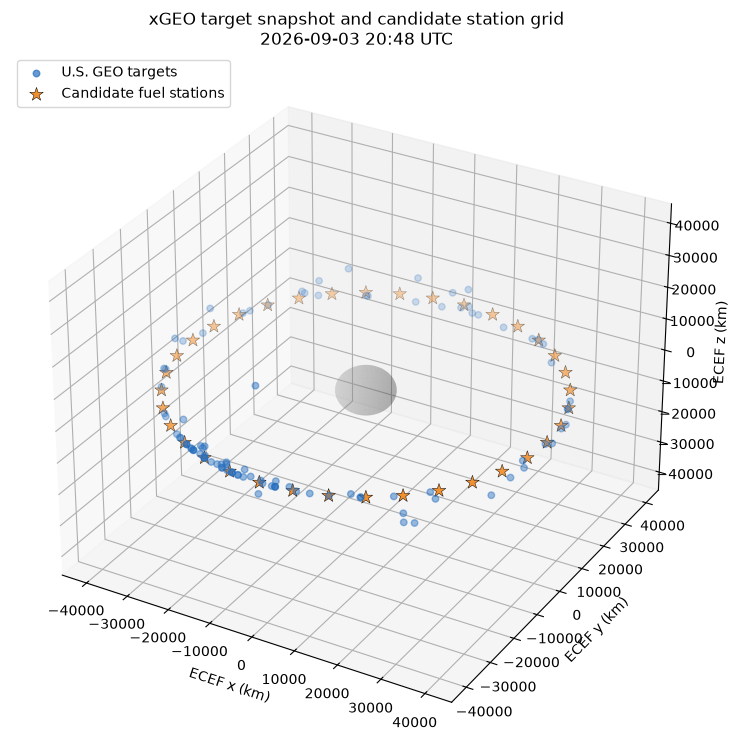

In [6]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(targets['X_ECEF_KM'], targets['Y_ECEF_KM'], targets['Z_ECEF_KM'], s=22, color='#276FBF', alpha=0.70, label='U.S. GEO targets')
ax.scatter(stations['X_ECEF_KM'], stations['Y_ECEF_KM'], stations['Z_ECEF_KM'], marker='*', s=105, color='#F28E2B', edgecolor='black', linewidth=0.35, label='Candidate fuel stations')

earth_radius_km = 6_378.0
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
ax.plot_surface(earth_radius_km*np.cos(u)*np.sin(v), earth_radius_km*np.sin(u)*np.sin(v), earth_radius_km*np.cos(v), color='#A6A6A6', alpha=0.22, linewidth=0)

limit = 46_000
ax.set(xlim=(-limit, limit), ylim=(-limit, limit), zlim=(-limit, limit), xlabel='ECEF x (km)', ylabel='ECEF y (km)', zlabel='ECEF z (km)')
ax.set_title(f'xGEO target snapshot and candidate station grid\n{analysis_epoch:%Y-%m-%d %H:%M UTC}')
ax.legend(loc='upper left')
plt.show()

## 6. Define a one-way screening Δv model

For each station-target pair, the screening cost adds: (1) GEO phasing Δv for longitude separation, (2) plane-change Δv from equatorial GEO to the target inclination, and (3) a two-impulse semimajor-axis adjustment. It is a consistent ranking metric, not a fully optimized rendezvous trajectory.

In [7]:
def wrap_to_pi(angle_rad):
    return (np.asarray(angle_rad) + np.pi) % (2.0 * np.pi) - np.pi

def phasing_one_way_dv_km_s(angular_separation_rad, revolutions=PHASING_REVOLUTIONS):
    separation = np.abs(wrap_to_pi(angular_separation_rad))
    geo_period_s = 2.0 * np.pi * np.sqrt(GEO_RADIUS_KM**3 / MU_EARTH_KM3_S2)
    geo_speed = np.sqrt(MU_EARTH_KM3_S2 / GEO_RADIUS_KM)
    period_inner = geo_period_s * (1.0 - separation / (2.0 * np.pi * revolutions))
    period_outer = geo_period_s * (1.0 + separation / (2.0 * np.pi * revolutions))

    def transfer_dv(period):
        a_phase = (MU_EARTH_KM3_S2 * (period / (2.0 * np.pi))**2)**(1.0 / 3.0)
        speed_at_geo = np.sqrt(MU_EARTH_KM3_S2 * (2.0 / GEO_RADIUS_KM - 1.0 / a_phase))
        return 2.0 * np.abs(speed_at_geo - geo_speed)

    return np.minimum(transfer_dv(period_inner), transfer_dv(period_outer))

def hohmann_dv_km_s(r1_km, r2_km):
    dv1 = np.sqrt(MU_EARTH_KM3_S2 / r1_km) * (np.sqrt(2.0 * r2_km / (r1_km + r2_km)) - 1.0)
    dv2 = np.sqrt(MU_EARTH_KM3_S2 / r2_km) * (1.0 - np.sqrt(2.0 * r1_km / (r1_km + r2_km)))
    return np.abs(dv1) + np.abs(dv2)

def candidate_station_cost_matrix(targets, stations):
    target_longitude = targets['LONGITUDE_RAD'].to_numpy()[:, None]
    station_longitude = np.deg2rad(stations['LONGITUDE_DEG'].to_numpy())[None, :]
    longitude_dv = phasing_one_way_dv_km_s(target_longitude - station_longitude)

    target_inclination = np.deg2rad(targets['INCLINATION'].to_numpy())[:, None]
    geo_speed = np.sqrt(MU_EARTH_KM3_S2 / GEO_RADIUS_KM)
    plane_change_dv = 2.0 * geo_speed * np.sin(target_inclination / 2.0)

    target_a = targets['SEMIMAJOR_AXIS'].to_numpy()[:, None]
    radial_dv = hohmann_dv_km_s(GEO_RADIUS_KM, target_a)

    return longitude_dv + plane_change_dv + radial_dv


## 7. Build, inspect, and export the cost matrix

Rows are satellites. Columns are candidate fuel stations. Every entry is the estimated **one-way** Δv in km/s for a servicing spacecraft to leave that station and rendezvous with that target.

In [8]:
cost_values = candidate_station_cost_matrix(targets, stations)
cost_matrix = pd.DataFrame(cost_values, index=targets['NORAD_CAT_ID'], columns=stations['STATION_ID'])
cost_matrix.index.name = 'NORAD_CAT_ID'

nearest_index = cost_values.argmin(axis=1)
nearest_station_summary = targets[['NORAD_CAT_ID', 'OBJECT_NAME', 'LONGITUDE_DEG', 'INCLINATION']].copy()
nearest_station_summary['NEAREST_STATION_ID'] = stations['STATION_ID'].to_numpy()[nearest_index]
nearest_station_summary['ONE_WAY_DV_KM_S'] = cost_values[np.arange(len(targets)), nearest_index]

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
targets.to_csv(OUTPUT_DIRECTORY / 'target_snapshot.csv', index=False)
stations.to_csv(OUTPUT_DIRECTORY / 'candidate_stations.csv', index=False)
cost_matrix.to_csv(OUTPUT_DIRECTORY / 'one_way_delta_v_cost_matrix_km_s.csv')
nearest_station_summary.to_csv(OUTPUT_DIRECTORY / 'nearest_candidate_station.csv', index=False)
excluded_targets.to_csv(OUTPUT_DIRECTORY / 'excluded_targets.csv', index=False)

print(f'Cost-matrix shape: {cost_matrix.shape[0]} targets x {cost_matrix.shape[1]} candidate stations')
print(f'Minimum one-way Δv: {cost_values.min():.4f} km/s')
print(f'Median nearest-station Δv: {nearest_station_summary["ONE_WAY_DV_KM_S"].median():.4f} km/s')
print(f'Outputs: {OUTPUT_DIRECTORY.resolve()}')
cost_matrix.iloc[:5, :6]

Cost-matrix shape: 102 targets x 36 candidate stations
Minimum one-way Δv: 0.0012 km/s
Median nearest-station Δv: 0.0646 km/s
Outputs: C:\Users\leo.langou\OneDrive - West Point\Desktop\2027 AY-1\MA498\Space_Logistics\outputs\xgeo_station_cost_matrix


STATION_ID,FS_01,FS_02,FS_03,FS_04,FS_05,FS_06
NORAD_CAT_ID,,,,,,
56372,0.577716,0.613315,0.647474,0.680284,0.711829,0.742183
41745,0.618470,0.655606,0.691203,0.725360,0.758168,0.789710
57479,0.392720,0.354261,0.314057,0.271977,0.227876,0.181594
55263,0.625189,0.653027,0.679890,0.673435,0.646340,0.618255
56370,0.415749,0.378315,0.339210,0.298312,0.255485,0.210579


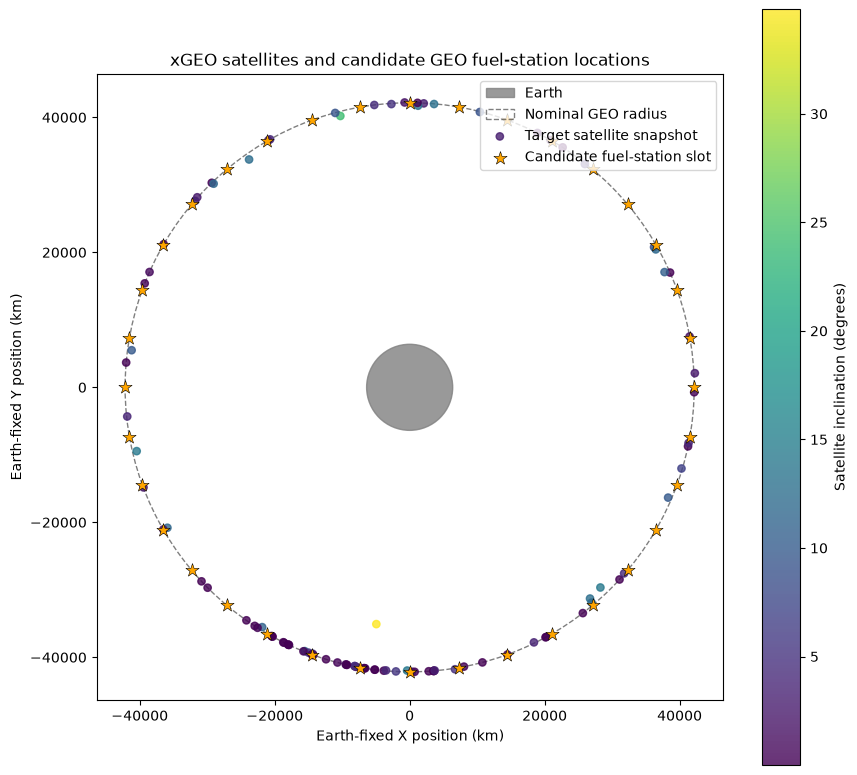

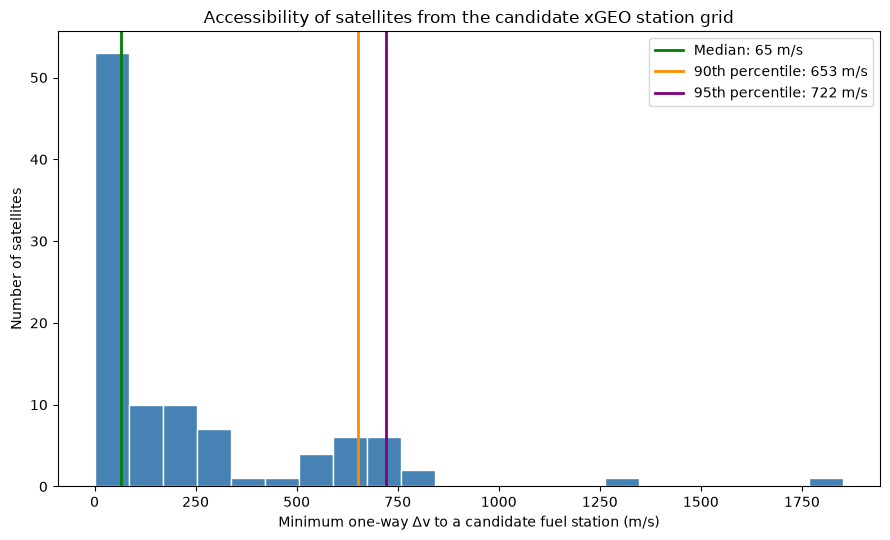

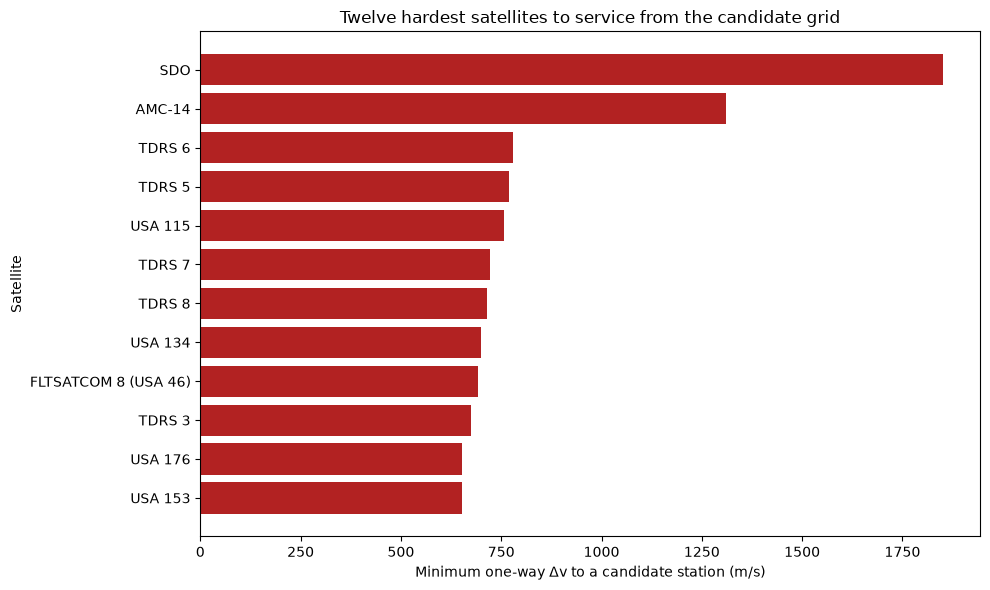

In [9]:
# %% STEP 8 — Initial-result visuals

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIGURE_DIRECTORY = OUTPUT_DIRECTORY / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

# Cheapest candidate station for each target
nearest_station = cost_matrix.idxmin(axis=1)
nearest_dv_km_s = cost_matrix.min(axis=1)

plot_targets = targets.copy().set_index("NORAD_CAT_ID")
plot_targets["NEAREST_STATION"] = nearest_station
plot_targets["NEAREST_DV_KM_S"] = nearest_dv_km_s
plot_targets = plot_targets.reset_index()

station_longitudes = stations.set_index("STATION_ID")["LONGITUDE_DEG"].to_dict()

# ---------------------------------------------------------
# FIGURE 1 — xGEO target snapshot and candidate station grid
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 8))

earth = plt.Circle((0, 0), 6378.0, color="gray", alpha=0.8, label="Earth")
geo_ring = plt.Circle(
    (0, 0),
    GEO_RADIUS_KM,
    fill=False,
    color="black",
    linestyle="--",
    alpha=0.5,
    label="Nominal GEO radius",
)

ax.add_patch(earth)
ax.add_patch(geo_ring)

targets_plot = ax.scatter(
    plot_targets["X_ECEF_KM"],
    plot_targets["Y_ECEF_KM"],
    c=plot_targets["INCLINATION"],
    cmap="viridis",
    s=28,
    alpha=0.8,
    label="Target satellite snapshot",
)

ax.scatter(
    stations["X_ECEF_KM"],
    stations["Y_ECEF_KM"],
    marker="*",
    s=100,
    color="orange",
    edgecolor="black",
    linewidth=0.4,
    label="Candidate fuel-station slot",
)

ax.set_aspect("equal")
ax.set_xlabel("Earth-fixed X position (km)")
ax.set_ylabel("Earth-fixed Y position (km)")
ax.set_title("xGEO satellites and candidate GEO fuel-station locations")
ax.legend(loc="upper right")

colorbar = fig.colorbar(targets_plot, ax=ax)
colorbar.set_label("Satellite inclination (degrees)")

plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "01_xgeo_snapshot_candidate_grid.png", dpi=250)
plt.show()


# ---------------------------------------------------------
# FIGURE 2 — Distribution of nearest-station maneuver cost
# ---------------------------------------------------------
median_dv = np.percentile(plot_targets["NEAREST_DV_KM_S"], 50)
p90_dv = np.percentile(plot_targets["NEAREST_DV_KM_S"], 90)
p95_dv = np.percentile(plot_targets["NEAREST_DV_KM_S"], 95)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(
    plot_targets["NEAREST_DV_KM_S"] * 1000,
    bins=22,
    color="steelblue",
    edgecolor="white",
)

ax.axvline(
    median_dv * 1000,
    color="green",
    linewidth=2,
    label=f"Median: {median_dv * 1000:.0f} m/s",
)

ax.axvline(
    p90_dv * 1000,
    color="darkorange",
    linewidth=2,
    label=f"90th percentile: {p90_dv * 1000:.0f} m/s",
)

ax.axvline(
    p95_dv * 1000,
    color="purple",
    linewidth=2,
    label=f"95th percentile: {p95_dv * 1000:.0f} m/s",
)

ax.set_xlabel("Minimum one-way Δv to a candidate fuel station (m/s)")
ax.set_ylabel("Number of satellites")
ax.set_title("Accessibility of satellites from the candidate xGEO station grid")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "02_nearest_station_delta_v_distribution.png", dpi=250)
plt.show()


# ---------------------------------------------------------
# FIGURE 3 — The satellites with the highest servicing cost
# ---------------------------------------------------------
hardest_targets = (
    plot_targets.nlargest(12, "NEAREST_DV_KM_S")
    .sort_values("NEAREST_DV_KM_S")
)

fig, ax = plt.subplots(figsize=(10, 6))

names = hardest_targets["OBJECT_NAME"].fillna(
    hardest_targets["NORAD_CAT_ID"].astype(str)
)

ax.barh(
    names,
    hardest_targets["NEAREST_DV_KM_S"] * 1000,
    color="firebrick",
)

ax.set_xlabel("Minimum one-way Δv to a candidate station (m/s)")
ax.set_ylabel("Satellite")
ax.set_title("Twelve hardest satellites to service from the candidate grid")

plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "03_high_cost_targets.png", dpi=250)
plt.show()

In [10]:
# %% STEP 9 — Static facility-location and T0 graph-filtration study

from itertools import combinations
import json

# Start with three stations. This runs quickly because there are
# C(36, 3) = 7,140 possible candidate combinations.
P_DEPOTS = 3

# Each target should have at least q reachable selected depots.
REDUNDANCY_Q = 2

# Operational screening threshold for a one-way transfer.
# Change this later to test 0.25, 0.50, 0.75, and 1.00 km/s.
COVERAGE_THRESHOLD_KM_S = 0.50

# The supplied catalog has no real refueling-demand values yet,
# so every target receives equal importance in this first study.
TARGET_WEIGHTS = np.ones(len(targets), dtype=float)

if P_DEPOTS < REDUNDANCY_Q:
    raise ValueError("P_DEPOTS must be at least REDUNDANCY_Q.")

# Ensure matrix rows follow the same target order as `targets`.
target_ids = targets["NORAD_CAT_ID"].astype(str).to_numpy()

cost_matrix_static = cost_matrix.copy()
cost_matrix_static.index = cost_matrix_static.index.astype(str)

cost_values_static = cost_matrix_static.loc[target_ids].to_numpy(dtype=float)
candidate_station_ids = cost_matrix_static.columns.to_numpy()

print(f"Targets: {len(targets)}")
print(f"Candidate GEO stations: {len(candidate_station_ids)}")
print(f"Stations to select: {P_DEPOTS}")
print(f"Required redundancy: {REDUNDANCY_Q}")
print(f"Coverage threshold: {COVERAGE_THRESHOLD_KM_S * 1000:.0f} m/s")

Targets: 102
Candidate GEO stations: 36
Stations to select: 3
Required redundancy: 2
Coverage threshold: 500 m/s


In [11]:
# %% STEP 10 — Exact p-median baseline

def weighted_mean(values, weights):
    return float(np.average(values, weights=weights))


def solve_exact_p_median(cost_values, depot_count, weights):
    """
    Select `depot_count` candidate stations that minimize the weighted
    mean one-way cost to each target's nearest selected station.
    """
    best_selection = None
    best_mean_primary_dv = np.inf

    for selection in combinations(range(cost_values.shape[1]), depot_count):
        selected_costs = cost_values[:, selection]
        primary_costs = selected_costs.min(axis=1)

        mean_primary_dv = weighted_mean(primary_costs, weights)

        if mean_primary_dv < best_mean_primary_dv:
            best_mean_primary_dv = mean_primary_dv
            best_selection = np.array(selection, dtype=int)

    return best_selection, best_mean_primary_dv


selected_indices, mean_primary_dv_km_s = solve_exact_p_median(
    cost_values_static,
    P_DEPOTS,
    TARGET_WEIGHTS,
)

selected_station_ids = candidate_station_ids[selected_indices]

print("Selected candidate stations:")
print(list(selected_station_ids))
print(f"Mean primary one-way Δv: {mean_primary_dv_km_s * 1000:.1f} m/s")

Selected candidate stations:
['FS_09', 'FS_18', 'FS_29']
Mean primary one-way Δv: 317.9 m/s


In [12]:
# %% STEP 11 — Assignment and resilience metrics

selected_costs = cost_values_static[:, selected_indices]

# Sort each target's costs to the selected stations.
ordered_selected_costs = np.sort(selected_costs, axis=1)

primary_costs_km_s = ordered_selected_costs[:, 0]
backup_costs_km_s = ordered_selected_costs[:, REDUNDANCY_Q - 1]

nearest_selected_local_index = selected_costs.argmin(axis=1)
primary_station_ids = selected_station_ids[nearest_selected_local_index]

coverage_counts = (
    selected_costs <= COVERAGE_THRESHOLD_KM_S
).sum(axis=1)

# N-1 test: remove one selected station at a time and recalculate
# each target's best remaining station.
single_failure_mean_costs = []

for failed_local_index in range(P_DEPOTS):
    surviving_costs = np.delete(
        selected_costs,
        failed_local_index,
        axis=1,
    )
    surviving_primary_costs = surviving_costs.min(axis=1)

    single_failure_mean_costs.append(
        weighted_mean(surviving_primary_costs, TARGET_WEIGHTS)
    )

worst_single_failure_mean_km_s = max(single_failure_mean_costs)

service_summary = targets[
    [
        "NORAD_CAT_ID",
        "OBJECT_NAME",
        "LONGITUDE_DEG",
        "INCLINATION",
        "SEMIMAJOR_AXIS",
        "X_ECEF_KM",
        "Y_ECEF_KM",
        "Z_ECEF_KM",
    ]
].copy()

service_summary["PRIMARY_STATION_ID"] = primary_station_ids
service_summary["PRIMARY_DV_KM_S"] = primary_costs_km_s
service_summary["BACKUP_DV_KM_S"] = backup_costs_km_s
service_summary["DEPOTS_WITHIN_THRESHOLD"] = coverage_counts
service_summary["Q_COVERED"] = coverage_counts >= REDUNDANCY_Q

selected_station_locations = (
    stations
    .set_index("STATION_ID")
    .loc[selected_station_ids]
    .reset_index()
)

metrics_table = pd.DataFrame(
    {
        "metric": [
            "mean_primary_one_way_dv_m_s",
            "mean_backup_one_way_dv_m_s",
            "worst_primary_one_way_dv_m_s",
            "worst_single_failure_mean_dv_m_s",
            "q_coverage_fraction",
            "targets_without_q_coverage",
        ],
        "value": [
            weighted_mean(primary_costs_km_s, TARGET_WEIGHTS) * 1000,
            weighted_mean(backup_costs_km_s, TARGET_WEIGHTS) * 1000,
            primary_costs_km_s.max() * 1000,
            worst_single_failure_mean_km_s * 1000,
            np.average(
                service_summary["Q_COVERED"].astype(float),
                weights=TARGET_WEIGHTS,
            ),
            int((~service_summary["Q_COVERED"]).sum()),
        ],
    }
)

display(metrics_table)
display(selected_station_locations[["STATION_ID", "LONGITUDE_DEG"]])

,metric,value
0,mean_primary_one_way_dv_m_s,317.853236
1,mean_backup_one_way_dv_m_s,615.659854
2,worst_primary_one_way_dv_m_s,1850.733353
3,worst_single_failure_mean_dv_m_s,504.725811
4,q_coverage_fraction,0.480392
5,targets_without_q_coverage,53.000000


,STATION_ID,LONGITUDE_DEG
0,FS_09,-100.0
1,FS_18,-10.0
2,FS_29,100.0


In [13]:
# %% STEP 12 — Betti numbers of the thresholded bipartite service graph

def graph_betti_numbers(cost_values, selected_indices, epsilon_km_s):
    """
    Build the bipartite target-depot graph at a transfer threshold epsilon.

    beta_0 = number of connected components
    beta_1 = number of independent graph cycles
    """
    customer_count = cost_values.shape[0]
    depot_count = len(selected_indices)
    vertex_count = customer_count + depot_count

    parent = np.arange(vertex_count)
    rank = np.zeros(vertex_count, dtype=int)

    def find(node):
        while parent[node] != node:
            parent[node] = parent[parent[node]]
            node = parent[node]
        return node

    def union(left, right):
        root_left = find(left)
        root_right = find(right)

        if root_left == root_right:
            return

        if rank[root_left] < rank[root_right]:
            root_left, root_right = root_right, root_left

        parent[root_right] = root_left

        if rank[root_left] == rank[root_right]:
            rank[root_left] += 1

    edge_count = 0

    for target_index in range(customer_count):
        for local_depot_index, global_depot_index in enumerate(selected_indices):
            if cost_values[target_index, global_depot_index] <= epsilon_km_s:
                edge_count += 1

                target_node = target_index
                depot_node = customer_count + local_depot_index

                union(target_node, depot_node)

    beta_0 = len({find(node) for node in range(vertex_count)})
    beta_1 = max(0, edge_count - vertex_count + beta_0)

    return {
        "epsilon_km_s": float(epsilon_km_s),
        "vertices": int(vertex_count),
        "edges": int(edge_count),
        "beta_0": int(beta_0),
        "beta_1": int(beta_1),
    }


topology_at_operational_threshold = graph_betti_numbers(
    cost_values_static,
    selected_indices,
    COVERAGE_THRESHOLD_KM_S,
)

print("Topology at the operational threshold:")
print(topology_at_operational_threshold)

Topology at the operational threshold:
{'epsilon_km_s': 0.5, 'vertices': 105, 'edges': 131, 'beta_0': 23, 'beta_1': 49}


In [14]:
# %% STEP 13 — T0 graph filtration

def weighted_fraction(boolean_values, weights):
    return float(
        np.average(
            np.asarray(boolean_values, dtype=float),
            weights=weights,
        )
    )


max_epsilon_km_s = selected_costs.max() * 1.02

epsilons_km_s = np.linspace(
    0.0,
    max_epsilon_km_s,
    160,
)

topology_curve = pd.DataFrame(
    [
        graph_betti_numbers(
            cost_values_static,
            selected_indices,
            epsilon_km_s,
        )
        for epsilon_km_s in epsilons_km_s
    ]
)

topology_curve["q_coverage_fraction"] = [
    weighted_fraction(
        (selected_costs <= epsilon_km_s).sum(axis=1) >= REDUNDANCY_Q,
        TARGET_WEIGHTS,
    )
    for epsilon_km_s in epsilons_km_s
]

topology_curve["mean_reachable_depots"] = [
    np.average(
        (selected_costs <= epsilon_km_s).sum(axis=1),
        weights=TARGET_WEIGHTS,
    )
    for epsilon_km_s in epsilons_km_s
]

display(topology_curve.head())

,epsilon_km_s,vertices,edges,beta_0,beta_1,q_coverage_fraction,mean_reachable_depots
0,0.000000,105,0,105,0,0.0,0.000000
1,0.015914,105,5,100,0,0.0,0.049020
2,0.031827,105,10,95,0,0.0,0.098039
3,0.047741,105,11,94,0,0.0,0.107843
4,0.063654,105,17,88,0,0.0,0.166667


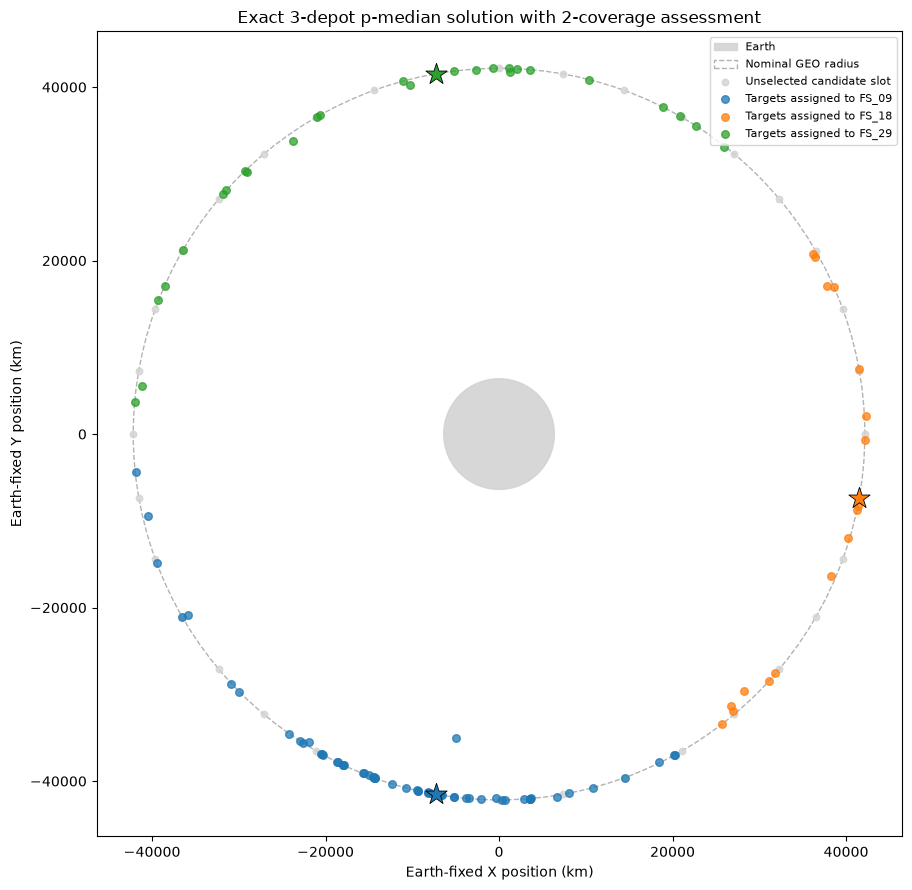

In [15]:
# %% STEP 14 — Static placement visualization

fig, ax = plt.subplots(figsize=(10, 9))

earth = plt.Circle(
    (0, 0),
    6_378.0,
    color="lightgray",
    alpha=0.9,
    label="Earth",
)

geo_ring = plt.Circle(
    (0, 0),
    GEO_RADIUS_KM,
    fill=False,
    color="gray",
    linestyle="--",
    alpha=0.6,
    label="Nominal GEO radius",
)

ax.add_patch(earth)
ax.add_patch(geo_ring)

# Candidate stations not selected by the p-median solution.
unselected_stations = stations[
    ~stations["STATION_ID"].isin(selected_station_ids)
]

ax.scatter(
    unselected_stations["X_ECEF_KM"],
    unselected_stations["Y_ECEF_KM"],
    s=22,
    color="lightgray",
    alpha=0.8,
    label="Unselected candidate slot",
)

# Targets receive the color of their assigned primary station.
colors = plt.cm.tab10(np.arange(P_DEPOTS))

for local_index, station_id in enumerate(selected_station_ids):
    assigned_targets = service_summary[
        service_summary["PRIMARY_STATION_ID"] == station_id
    ]

    ax.scatter(
        assigned_targets["X_ECEF_KM"],
        assigned_targets["Y_ECEF_KM"],
        s=30,
        color=colors[local_index],
        alpha=0.75,
        label=f"Targets assigned to {station_id}",
    )

    depot = selected_station_locations[
        selected_station_locations["STATION_ID"] == station_id
    ]

    ax.scatter(
        depot["X_ECEF_KM"],
        depot["Y_ECEF_KM"],
        marker="*",
        s=260,
        color=colors[local_index],
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
    )

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Earth-fixed X position (km)")
ax.set_ylabel("Earth-fixed Y position (km)")
ax.set_title(
    f"Exact {P_DEPOTS}-depot p-median solution "
    f"with {REDUNDANCY_Q}-coverage assessment"
)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIRECTORY / "static_t0_selected_station_assignments.png",
    dpi=250,
)
plt.show()

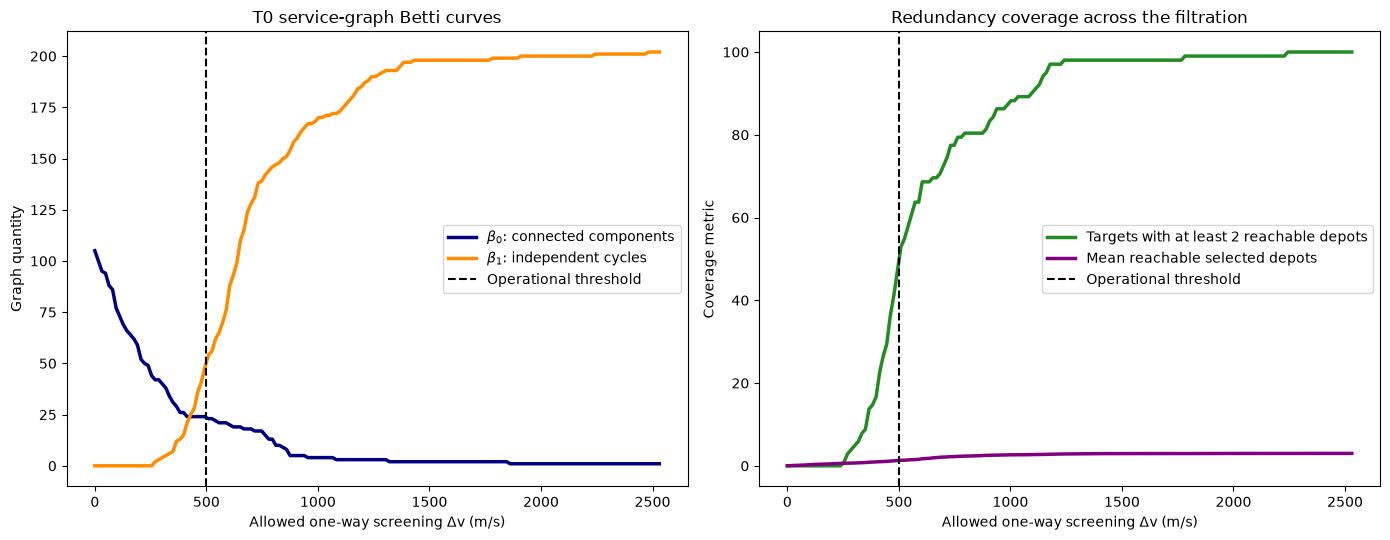

In [16]:
# %% STEP 15 — T0 graph-filtration results

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Betti curves
axes[0].plot(
    topology_curve["epsilon_km_s"] * 1000,
    topology_curve["beta_0"],
    linewidth=2.5,
    color="navy",
    label=r"$\beta_0$: connected components",
)

axes[0].plot(
    topology_curve["epsilon_km_s"] * 1000,
    topology_curve["beta_1"],
    linewidth=2.5,
    color="darkorange",
    label=r"$\beta_1$: independent cycles",
)

axes[0].axvline(
    COVERAGE_THRESHOLD_KM_S * 1000,
    color="black",
    linestyle="--",
    label="Operational threshold",
)

axes[0].set_xlabel("Allowed one-way screening Δv (m/s)")
axes[0].set_ylabel("Graph quantity")
axes[0].set_title("T0 service-graph Betti curves")
axes[0].legend()

# Explicit redundancy coverage
axes[1].plot(
    topology_curve["epsilon_km_s"] * 1000,
    100 * topology_curve["q_coverage_fraction"],
    linewidth=2.5,
    color="forestgreen",
    label=f"Targets with at least {REDUNDANCY_Q} reachable depots",
)

axes[1].plot(
    topology_curve["epsilon_km_s"] * 1000,
    topology_curve["mean_reachable_depots"],
    linewidth=2.5,
    color="purple",
    label="Mean reachable selected depots",
)

axes[1].axvline(
    COVERAGE_THRESHOLD_KM_S * 1000,
    color="black",
    linestyle="--",
    label="Operational threshold",
)

axes[1].set_xlabel("Allowed one-way screening Δv (m/s)")
axes[1].set_ylabel("Coverage metric")
axes[1].set_title("Redundancy coverage across the filtration")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIRECTORY / "static_t0_betti_and_coverage_curves.png",
    dpi=250,
)
plt.show()

In [17]:
# %% STEP 16 — Export static study outputs

STATIC_STUDY_DIRECTORY = OUTPUT_DIRECTORY / "static_t0_study"
STATIC_STUDY_DIRECTORY.mkdir(parents=True, exist_ok=True)

service_summary.to_csv(
    STATIC_STUDY_DIRECTORY / "target_assignments_and_redundancy.csv",
    index=False,
)

selected_station_locations.to_csv(
    STATIC_STUDY_DIRECTORY / "selected_station_locations.csv",
    index=False,
)

topology_curve.to_csv(
    STATIC_STUDY_DIRECTORY / "betti_and_coverage_curve.csv",
    index=False,
)

metrics_table.to_csv(
    STATIC_STUDY_DIRECTORY / "static_study_metrics.csv",
    index=False,
)

study_summary = {
    "model_scope": (
        "Static F0 screening study. The cost matrix is a snapshot-based "
        "surrogate, not a validated time-dependent rendezvous solution."
    ),
    "depot_count": int(P_DEPOTS),
    "redundancy_q": int(REDUNDANCY_Q),
    "coverage_threshold_km_s": float(COVERAGE_THRESHOLD_KM_S),
    "selected_station_ids": selected_station_ids.tolist(),
    "selected_station_longitudes_deg": selected_station_locations[
        "LONGITUDE_DEG"
    ].tolist(),
    "topology_at_operational_threshold": topology_at_operational_threshold,
    "metrics": {
        row["metric"]: float(row["value"])
        for _, row in metrics_table.iterrows()
    },
}

with (
    STATIC_STUDY_DIRECTORY / "static_study_summary.json"
).open("w", encoding="utf-8") as handle:
    json.dump(study_summary, handle, indent=2)

print(f"Saved static-study outputs to: {STATIC_STUDY_DIRECTORY.resolve()}")

Saved static-study outputs to: C:\Users\leo.langou\OneDrive - West Point\Desktop\2027 AY-1\MA498\Space_Logistics\outputs\xgeo_station_cost_matrix\static_t0_study


In [18]:
# %% STEP 17 — Static facility-location helpers

def weighted_mean(values, weights):
    return float(np.average(values, weights=weights))


def selection_metrics(
    cost_values,
    selected_indices,
    weights,
    redundancy_q,
    coverage_threshold_km_s,
):
    """
    Evaluate one fixed station set. This does not optimize anything.
    """
    selected_indices = np.asarray(selected_indices, dtype=int)

    if len(selected_indices) < redundancy_q:
        raise ValueError("The selected station count must be at least redundancy_q.")

    selected_costs = cost_values[:, selected_indices]
    ordered_costs = np.sort(selected_costs, axis=1)

    primary_costs = ordered_costs[:, 0]
    backup_costs = ordered_costs[:, redundancy_q - 1]

    reachable_depot_counts = (
        selected_costs <= coverage_threshold_km_s
    ).sum(axis=1)

    q_covered = reachable_depot_counts >= redundancy_q

    # N-1 result: remove one selected depot at a time.
    failure_mean_costs = []

    for failed_local_index in range(len(selected_indices)):
        surviving_costs = np.delete(
            selected_costs,
            failed_local_index,
            axis=1,
        )

        failure_mean_costs.append(
            weighted_mean(
                surviving_costs.min(axis=1),
                weights,
            )
        )

    return {
        "mean_primary_km_s": weighted_mean(primary_costs, weights),
        "mean_backup_km_s": weighted_mean(backup_costs, weights),
        "worst_primary_km_s": float(primary_costs.max()),
        "q_coverage_fraction": weighted_mean(
            q_covered.astype(float),
            weights,
        ),
        "targets_without_q_coverage": int((~q_covered).sum()),
        "targets_with_zero_reachable_depots": int(
            (reachable_depot_counts == 0).sum()
        ),
        "worst_single_failure_mean_km_s": max(failure_mean_costs),
    }


def solve_exact_p_median(cost_values, depot_count, weights):
    """
    Select stations that minimize weighted mean primary one-way Δv.
    """
    best_indices = None
    best_mean_primary = np.inf

    for selection in combinations(
        range(cost_values.shape[1]),
        depot_count,
    ):
        selection = np.asarray(selection, dtype=int)

        mean_primary = weighted_mean(
            cost_values[:, selection].min(axis=1),
            weights,
        )

        if mean_primary < best_mean_primary:
            best_mean_primary = mean_primary
            best_indices = selection

    return best_indices


def solve_cost_minimum_with_q_coverage(
    cost_values,
    depot_count,
    weights,
    redundancy_q,
    coverage_threshold_km_s,
    minimum_q_coverage_fraction,
):
    """
    Minimize mean primary Δv, subject to a minimum q-coverage fraction.

    Example:
    minimum_q_coverage_fraction = 0.60
    means at least 60% of targets must reach q selected stations.
    """
    best_indices = None
    best_key = None

    for selection in combinations(
        range(cost_values.shape[1]),
        depot_count,
    ):
        selection = np.asarray(selection, dtype=int)
        selected_costs = cost_values[:, selection]

        q_covered = (
            selected_costs <= coverage_threshold_km_s
        ).sum(axis=1) >= redundancy_q

        q_coverage_fraction = weighted_mean(
            q_covered.astype(float),
            weights,
        )

        if q_coverage_fraction < minimum_q_coverage_fraction:
            continue

        mean_primary = weighted_mean(
            selected_costs.min(axis=1),
            weights,
        )

        mean_backup = weighted_mean(
            np.sort(selected_costs, axis=1)[:, redundancy_q - 1],
            weights,
        )

        # First minimize primary cost; then use backup cost as a tie-breaker.
        candidate_key = (mean_primary, mean_backup)

        if best_key is None or candidate_key < best_key:
            best_key = candidate_key
            best_indices = selection

    if best_indices is None:
        raise ValueError(
            "No station combination satisfies the requested q-coverage target. "
            "Lower the target, raise the threshold, or add stations."
        )

    return best_indices

In [19]:
# %% STEP 18 — p-median sensitivity sweep

# Keep this at 2 through 5 initially.
# Five stations requires checking 376,992 combinations and should still run.
DEPOT_COUNTS_TO_TEST = range(2, 6)

sensitivity_records = []

for depot_count in DEPOT_COUNTS_TO_TEST:
    print(f"Solving exact p-median for p = {depot_count}...")

    p_median_indices = solve_exact_p_median(
        cost_values_static,
        depot_count,
        TARGET_WEIGHTS,
    )

    metrics = selection_metrics(
        cost_values_static,
        p_median_indices,
        TARGET_WEIGHTS,
        REDUNDANCY_Q,
        COVERAGE_THRESHOLD_KM_S,
    )

    topology = graph_betti_numbers(
        cost_values_static,
        p_median_indices,
        COVERAGE_THRESHOLD_KM_S,
    )

    sensitivity_records.append(
        {
            "depot_count": depot_count,
            "selected_stations": ", ".join(
                candidate_station_ids[p_median_indices]
            ),
            "mean_primary_dv_m_s": (
                metrics["mean_primary_km_s"] * 1000
            ),
            "mean_backup_dv_m_s": (
                metrics["mean_backup_km_s"] * 1000
            ),
            "worst_primary_dv_m_s": (
                metrics["worst_primary_km_s"] * 1000
            ),
            "q_coverage_percent": (
                100 * metrics["q_coverage_fraction"]
            ),
            "targets_without_q_coverage": (
                metrics["targets_without_q_coverage"]
            ),
            "zero_reachable_targets": (
                metrics["targets_with_zero_reachable_depots"]
            ),
            "worst_single_failure_mean_dv_m_s": (
                metrics["worst_single_failure_mean_km_s"] * 1000
            ),
            "beta_0": topology["beta_0"],
            "beta_1": topology["beta_1"],
        }
    )

p_sensitivity = pd.DataFrame(sensitivity_records)

display(p_sensitivity)

Solving exact p-median for p = 2...
Solving exact p-median for p = 3...
Solving exact p-median for p = 4...
Solving exact p-median for p = 5...


,depot_count,selected_stations,mean_primary_dv_m_s,mean_backup_dv_m_s,worst_primary_dv_m_s,q_coverage_percent,targets_without_q_coverage,zero_reachable_targets,worst_single_failure_mean_dv_m_s,beta_0,beta_1
0,2,"FS_09, FS_28",351.605425,800.664261,1850.733353,4.901961,97,26,682.601970,27,4
1,3,"FS_09, FS_18, FS_29",317.853236,615.659854,1850.733353,48.039216,53,22,504.725811,23,49
2,4,"FS_09, FS_18, FS_28, FS_34",296.118610,551.398899,1850.733353,62.745098,38,21,465.103741,22,95
3,5,"FS_08, FS_11, FS_19, FS_28, FS_33",278.078303,415.263633,1905.539339,73.529412,27,21,322.388956,22,133


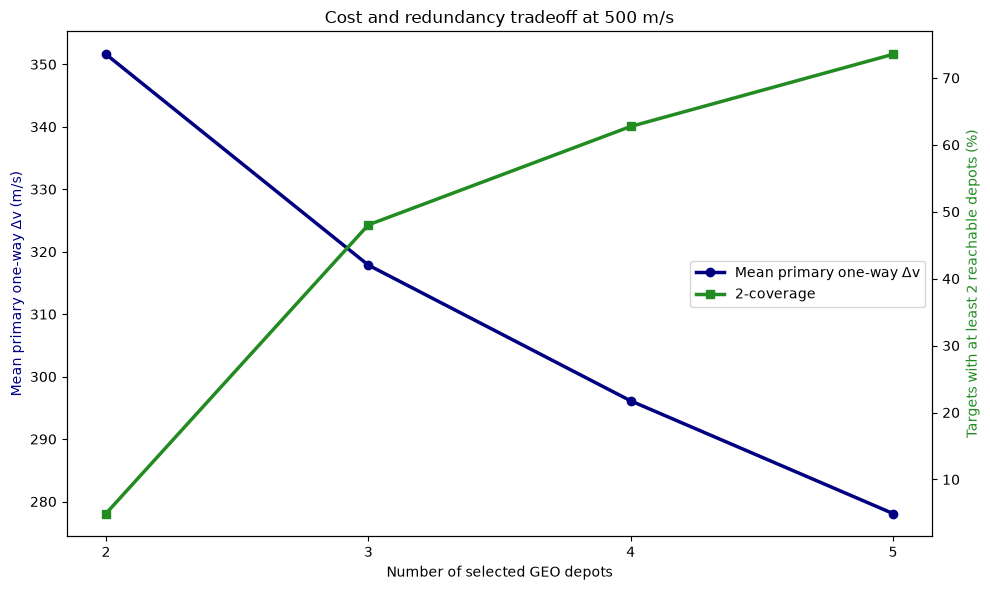

In [20]:
# %% STEP 19 — Depot-count tradeoff figure

fig, ax_cost = plt.subplots(figsize=(10, 6))

ax_coverage = ax_cost.twinx()

cost_line = ax_cost.plot(
    p_sensitivity["depot_count"],
    p_sensitivity["mean_primary_dv_m_s"],
    marker="o",
    linewidth=2.5,
    color="navy",
    label="Mean primary one-way Δv",
)

coverage_line = ax_coverage.plot(
    p_sensitivity["depot_count"],
    p_sensitivity["q_coverage_percent"],
    marker="s",
    linewidth=2.5,
    color="forestgreen",
    label=f"{REDUNDANCY_Q}-coverage",
)

ax_cost.set_xlabel("Number of selected GEO depots")
ax_cost.set_ylabel("Mean primary one-way Δv (m/s)", color="navy")
ax_coverage.set_ylabel(
    f"Targets with at least {REDUNDANCY_Q} reachable depots (%)",
    color="forestgreen",
)

ax_cost.set_xticks(p_sensitivity["depot_count"])
ax_cost.set_title(
    f"Cost and redundancy tradeoff at "
    f"{COVERAGE_THRESHOLD_KM_S * 1000:.0f} m/s"
)

lines = cost_line + coverage_line
labels = [line.get_label() for line in lines]

ax_cost.legend(lines, labels, loc="center right")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIRECTORY / "static_p_sensitivity_cost_vs_coverage.png",
    dpi=250,
)
plt.show()

In [21]:
# %% STEP 20 — Coverage-constrained three-depot solution

CONSTRAINED_DEPOT_COUNT = 3
MINIMUM_Q_COVERAGE_FRACTION = 0.60

baseline_indices = solve_exact_p_median(
    cost_values_static,
    CONSTRAINED_DEPOT_COUNT,
    TARGET_WEIGHTS,
)

coverage_constrained_indices = solve_cost_minimum_with_q_coverage(
    cost_values_static,
    CONSTRAINED_DEPOT_COUNT,
    TARGET_WEIGHTS,
    REDUNDANCY_Q,
    COVERAGE_THRESHOLD_KM_S,
    MINIMUM_Q_COVERAGE_FRACTION,
)

baseline_metrics = selection_metrics(
    cost_values_static,
    baseline_indices,
    TARGET_WEIGHTS,
    REDUNDANCY_Q,
    COVERAGE_THRESHOLD_KM_S,
)

constrained_metrics = selection_metrics(
    cost_values_static,
    coverage_constrained_indices,
    TARGET_WEIGHTS,
    REDUNDANCY_Q,
    COVERAGE_THRESHOLD_KM_S,
)

baseline_topology = graph_betti_numbers(
    cost_values_static,
    baseline_indices,
    COVERAGE_THRESHOLD_KM_S,
)

constrained_topology = graph_betti_numbers(
    cost_values_static,
    coverage_constrained_indices,
    COVERAGE_THRESHOLD_KM_S,
)

station_longitudes = stations.set_index(
    "STATION_ID"
)["LONGITUDE_DEG"].to_dict()

comparison_table = pd.DataFrame(
    [
        {
            "method": "Lowest-cost p-median",
            "selected_stations": ", ".join(
                candidate_station_ids[baseline_indices]
            ),
            "station_longitudes_deg": ", ".join(
                f"{station_longitudes[station_id]:.0f}"
                for station_id in candidate_station_ids[baseline_indices]
            ),
            "mean_primary_dv_m_s": (
                baseline_metrics["mean_primary_km_s"] * 1000
            ),
            "mean_backup_dv_m_s": (
                baseline_metrics["mean_backup_km_s"] * 1000
            ),
            "q_coverage_percent": (
                100 * baseline_metrics["q_coverage_fraction"]
            ),
            "targets_without_q_coverage": (
                baseline_metrics["targets_without_q_coverage"]
            ),
            "worst_N_minus_1_mean_dv_m_s": (
                baseline_metrics[
                    "worst_single_failure_mean_km_s"
                ] * 1000
            ),
            "beta_0": baseline_topology["beta_0"],
            "beta_1": baseline_topology["beta_1"],
        },
        {
            "method": (
                f"Coverage-constrained "
                f"({MINIMUM_Q_COVERAGE_FRACTION:.0%} target)"
            ),
            "selected_stations": ", ".join(
                candidate_station_ids[coverage_constrained_indices]
            ),
            "station_longitudes_deg": ", ".join(
                f"{station_longitudes[station_id]:.0f}"
                for station_id in candidate_station_ids[
                    coverage_constrained_indices
                ]
            ),
            "mean_primary_dv_m_s": (
                constrained_metrics["mean_primary_km_s"] * 1000
            ),
            "mean_backup_dv_m_s": (
                constrained_metrics["mean_backup_km_s"] * 1000
            ),
            "q_coverage_percent": (
                100 * constrained_metrics["q_coverage_fraction"]
            ),
            "targets_without_q_coverage": (
                constrained_metrics["targets_without_q_coverage"]
            ),
            "worst_N_minus_1_mean_dv_m_s": (
                constrained_metrics[
                    "worst_single_failure_mean_km_s"
                ] * 1000
            ),
            "beta_0": constrained_topology["beta_0"],
            "beta_1": constrained_topology["beta_1"],
        },
    ]
)

display(comparison_table)

,method,selected_stations,station_longitudes_deg,mean_primary_dv_m_s,mean_backup_dv_m_s,q_coverage_percent,targets_without_q_coverage,worst_N_minus_1_mean_dv_m_s,beta_0,beta_1
0,Lowest-cost p-median,"FS_09, FS_18, FS_29","-100, -10, 100",317.853236,615.659854,48.039216,53,504.725811,23,49
1,Coverage-constrained (60% target),"FS_08, FS_12, FS_27","-110, -70, 80",326.543784,523.990713,60.784314,40,424.610867,24,63


In [22]:
# %% STEP 21 — Export sensitivity and comparison results

NEXT_STUDY_DIRECTORY = OUTPUT_DIRECTORY / "static_sensitivity_study"
NEXT_STUDY_DIRECTORY.mkdir(parents=True, exist_ok=True)

p_sensitivity.to_csv(
    NEXT_STUDY_DIRECTORY / "p_median_sensitivity.csv",
    index=False,
)

comparison_table.to_csv(
    NEXT_STUDY_DIRECTORY / "p_median_vs_coverage_constrained.csv",
    index=False,
)

print(f"Saved outputs to: {NEXT_STUDY_DIRECTORY.resolve()}")

Saved outputs to: C:\Users\leo.langou\OneDrive - West Point\Desktop\2027 AY-1\MA498\Space_Logistics\outputs\xgeo_station_cost_matrix\static_sensitivity_study
